In [2]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

from scipy.signal import find_peaks
from scipy.stats import percentileofscore
from statsmodels.stats.contingency_tables import mcnemar

from PIL import Image

import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [3]:
ssplist = ["370"]

ssplistplot = ["hist","370"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1980,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1970,2025]
baselineera_obs = [1950,1980]

inputlength = 10
outputavgtime = 10
# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

device = 'mps'


data/MPI_annualmean_370_tos_1900-2100.pkl


In [4]:

imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

gmtcorrection = AllObs.obs_gmt_correction()
correctionfactor = gmtcorrection[0]-gmtcorrection[-1]

lenobs = experiment_era_obs[1]-experiment_era_obs[0]-outputavgtime-inputlength+1

In [5]:
landmask = np.isnan(np.nanmean(AllObs.alloutput,axis=0)) | (latmesh<-55)

In [6]:
hindcastfilesin = sorted(glob.glob("../MPIhindcasts/data/MPIhindcast_summertime_tas_*.pkl"))

alldataALL = []

for ifile,filein in enumerate(hindcastfilesin[1:]):
    
    with open(filein,'rb') as f:
        indata = pickle.load(f)

    alldataALL.append(indata[0])

MPIforecastcut0 = experiment_era_obs[0]-1961
MPIforecastcut1 = experiment_era_obs[1]-2020

alldataALL= np.asarray(alldataALL)
if outputavgtime>5:
    # alldatacut = alldataALL[(MPIforecastcut0+inputlength):MPIforecastcut1-outputavgtime]
    alldatacut = alldataALL[(MPIforecastcut0+inputlength):]
elif outputavgtime==5:
    alldatacut = alldataALL[(MPIforecastcut0+inputlength):]
else:
    print('not able to do this lol')

leadtimebias = np.empty((alldatacut.shape[0],1,alldataALL.shape[2],alldataALL.shape[3],alldataALL.shape[4]))
leadtimebias[0] = np.mean(alldataALL[:MPIforecastcut0+inputlength],axis=(0,1),keepdims=True)

for itime in range(1,alldatacut.shape[0]):

    leadtimebias[itime] = np.mean(alldataALL[:MPIforecastcut0+inputlength+itime],axis=(0,1),keepdims=True)


#
alldata_corrected = alldatacut-leadtimebias
hindcast_summerclimo_anomish = np.mean(alldataALL[:30,:,0],axis=(0,1))-leadtimebias[:,:,[0]]

alldata_forecasts = alldatacut-leadtimebias-hindcast_summerclimo_anomish


In [7]:
def bb(forecast1,forecast2,verification,autocorr,nboots):

    nsamps = len(forecast1)
    nsampsgrab = int(np.round(nsamps/autocorr))

    fdiff = np.empty(nboots)
    # f2acc = np.empty(nboots)
    fbss = np.empty(nboots)
    # f2bs = np.empty(nboots)

    for iboot in range(nboots):
        sampsel = np.random.choice(nsamps-autocorr,nsampsgrab,replace=True)
        sampsel = (sampsel[:,np.newaxis]+np.arange(autocorr)).flatten()

        forecast1sel = forecast1[sampsel]
        forecast2sel = forecast2[sampsel]
        verifsel = verification[sampsel]

        fdiff[iboot] = np.mean(np.round(forecast1sel)==verifsel) - np.mean(np.round(forecast2sel)==verifsel)

        f1bs = helpers.brierscore(forecast1sel.squeeze(),verifsel.squeeze())
        f2bs = helpers.brierscore(forecast2sel.squeeze(),verifsel.squeeze())

        fbss[iboot] = 1-(f1bs/f2bs)

    return fdiff,fbss


In [8]:
nboots = 500
autocorr = 3

obsfirstpositive = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
MPIfirstpositive = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsfirstpositive_climo = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obsaccuracy_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obs_bs_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsclimo_bs_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsclimo_acc_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

lr_firstpositive = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

# lr_modelfilefront = "MPI_histrecord_"
lr_modelfilefront = "MPI_recordtemp_"

for ilat,lat in enumerate(AllObs.output_lat):

    for ilon,lon in enumerate(AllObs.output_lon):

        metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed*.json"
        filelist = glob.glob(metricsout)

        if (len(filelist)!=0) & (lat>-55):
            # print('models exist, proceeding')

            bestseeds = helpers.get_best_files(filelist,n_best)
            # obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)
            obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)

            obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
            obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
            obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
            obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)
            
            obsinput_climo = AllObs.cutinput
            obsinput_meaninput = np.mean(obsinput_climo,axis=0,keepdims=True)
            obsinput_meaninput_anom = torch.tensor(obsinput_meaninput-np.mean(obsinput_meaninput,axis=1,keepdims=True),dtype=torch.float32)
            obsinput_sstclimo = obsinput_meaninput_anom*torch.ones(obsinput_t.size())
            # obsinput_sstclimo = torch.mean(obsinput_t,axis=0,keepdims=True)*torch.ones(obsinput_t.size())


            obspredall = np.empty((3,len(obsinputgmt)))
            obspredclimo = np.empty((3,len(obsinputgmt)))

            for iseed,seed in enumerate(bestseeds):
                # load the model

                loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed_"+str(seed)+".pt"
                cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
                cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
                cnn.to(device)

                with torch.no_grad():
                    cnn.eval()
                    obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()
                    obspred_climo = cnn(obsinput_sstclimo.to(device), obsinputvectors_t.to(device)).cpu().numpy()

                obspredall[iseed] = obspred[:,1]
                obspredclimo[iseed] = obspred_climo[:,1]

            obspredavg = np.mean(obspredall,axis=0)
            obspredclass = np.round(obspredavg)

            obspredavg_climo = np.mean(obspredclimo,axis=0)
            obspredclass_climo = np.round(obspredavg_climo)

            obsfirstpositive[ilat,ilon] = helpers.firstpositive(obspredavg,obsinputgmt)
            
            obsfirstpositive_climo[ilat,ilon] = helpers.firstpositive(obspredavg_climo,obsinputgmt)

            if lat<0:
                MPIhindcast_maxdistribution = np.max(np.sort(alldata_forecasts[:,:,1:outputavgtime+1,ilat,ilon],axis=1),axis=2)
                lentime = len(obsinputpriorrecord)-5+1
                lentimechop = len(obsinputpriorrecord)-outputavgtime+1
                # lentime = len(obsinputpriorrecord)-1

                MPIconfs = np.empty(lentime)
                for itime in range(lentime):
                    MPIconfs[itime] = 100-percentileofscore(MPIhindcast_maxdistribution[itime].squeeze(),obsinputpriorrecord[:-(5-1)][itime].squeeze())
            else:
                MPIhindcast_maxdistribution = np.max(np.sort(alldata_forecasts[:,:,:outputavgtime,ilat,ilon],axis=1),axis=2)
                lentime = len(obsinputpriorrecord)-5
                lentimechop = len(obsinputpriorrecord)-outputavgtime
                # lentime = len(obsinputpriorrecord)

                MPIconfs = np.empty(lentime)
                for itime in range(lentime):
                    MPIconfs[itime] = 100-percentileofscore(MPIhindcast_maxdistribution[itime].squeeze(),obsinputpriorrecord[:-(5)][itime].squeeze())

            MPIconfs = MPIconfs/100
            MPIpredclass = np.round(MPIconfs)

            MPIfirstpositive[ilat,ilon] = helpers.firstpositive(MPIconfs,obsinputgmt[:lentime])

            obsaccuracy_bb[:,ilat,ilon],obs_bs_bb[:,ilat,ilon] = bb(
                obspredavg[:lentimechop],MPIconfs[:lentimechop],obsoutput[:lentime],autocorr,nboots)
            
            obsclimo_acc_bb[:,ilat,ilon],obsclimo_bs_bb[:,ilat,ilon] = bb(
                obspredavg[:lentimechop],obspredavg_climo,obsoutput[:lentime],autocorr,nboots)

            lrmodelload = "lr_models/"+lr_modelfilefront + "LogisticRegression_avgtime_"+str(outputavgtime)+"_lat_"+str(lat)+"_lon_"+str(lon)+".joblib"
            lrmodel = joblib.load(lrmodelload)

            lrpred = lrmodel.predict_proba(obsinputvectors_t[:,[0]].numpy())[:,1]
            lr_firstpositive[ilat,ilon] = helpers.firstpositive(lrpred,obsinputgmt)




/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpic

In [9]:
addgmtcorrection = True

if addgmtcorrection:

    obsfirstpositive = obsfirstpositive + correctionfactor
    MPIfirstpositive = MPIfirstpositive + correctionfactor
    obsfirstpositive_climo = obsfirstpositive_climo + correctionfactor

    cbarcorrection = [0.2,1.5]

else:
    cbarcorrection = [-0.15,1.1]

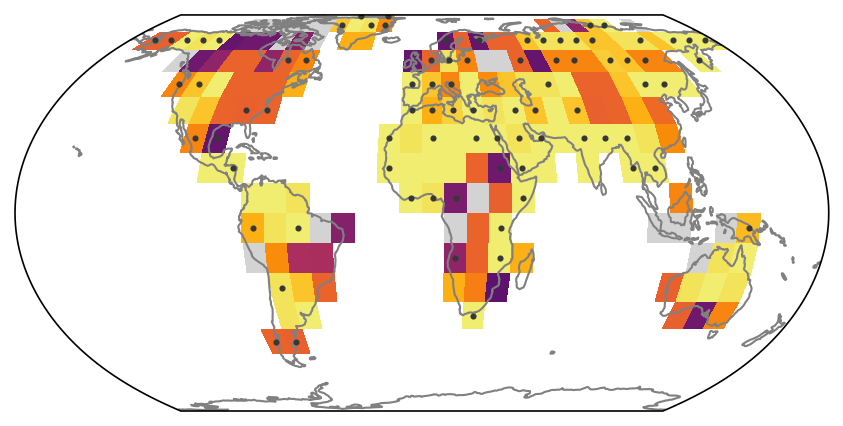

In [10]:

lonsig = lonmesh[(np.percentile(obs_bs_bb,10,axis=0)>0)&~(np.isnan(obsfirstpositive))]
latsig = latmesh[(np.percentile(obs_bs_bb,10,axis=0)>0)&~(np.isnan(obsfirstpositive))]

obsfirstpositive[landmask] = np.nan

plt.figure(figsize=(7,4))

# plt.figure(figsize=(7,7))


ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.set_facecolor('lightgrey') 
ocean_color = np.where(landmask, 0, np.nan) 

c1=ax.pcolormesh(lonvec+5,latvec+5,obsfirstpositive,vmin=cbarcorrection[0],vmax=cbarcorrection[1],cmap='inferno_r',transform=ccrs.PlateCarree())
ax.pcolormesh(lonvec + 5, latvec + 5, ocean_color, cmap='binary', vmin=0, vmax=1, transform=ccrs.PlateCarree(),label='data',zorder=0)
ax.coastlines(color='gray',zorder=1)

ax.scatter(lonsig,latsig,marker='.',color='xkcd:dark gray',transform=ccrs.PlateCarree(),label='CNN better than hindcast',s=15,zorder=2)


# dot_handle = mlines.Line2D([], [], color='xkcd:dark gray', marker='.', linestyle='None', 
#                            markersize=10, label='CNN improved over hindcast')

# grey_patch = mpatches.Patch(color='lightgrey', label='No emergence predicted')

# ax.legend(
#     handles=[dot_handle, grey_patch], 
#     loc='center left',             # Anchor the left edge of the legend box
#     bbox_to_anchor=(1.05, 0.5),    # Position it just past the right edge (1.0) of the map
#     frameon=True
# )

# cax = plt.axes((0.93,0.02,0.03,0.96))
# cbar=plt.colorbar(c1,cax,ticks=np.arange(0.3,1.8,0.3))
# cbar.ax.set_ylabel('GMT anomaly ($^{\circ}$C)')

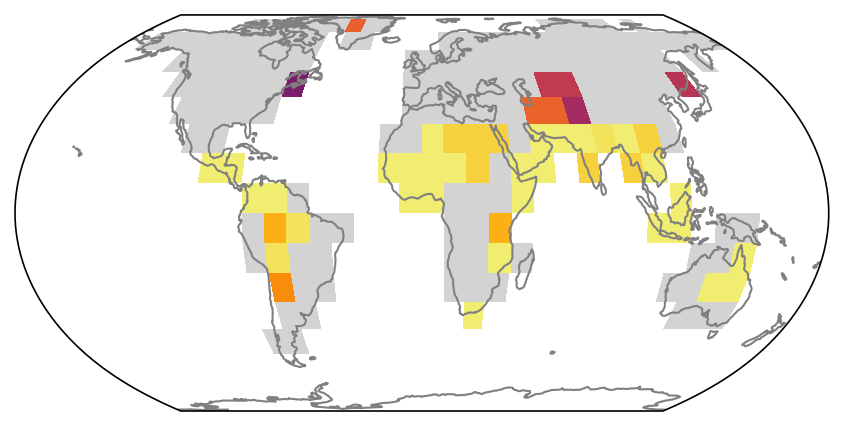

In [11]:
MPIfirstpositive[landmask] = np.nan

plt.figure(figsize=(7,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.set_facecolor('lightgrey')
ax.pcolormesh(lonvec+5,latvec+5,MPIfirstpositive,vmin=cbarcorrection[0],vmax=cbarcorrection[1],cmap='inferno_r',transform=ccrs.PlateCarree())
ax.pcolormesh(lonvec + 5, latvec + 5, ocean_color, cmap='binary', vmin=0, vmax=1, transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

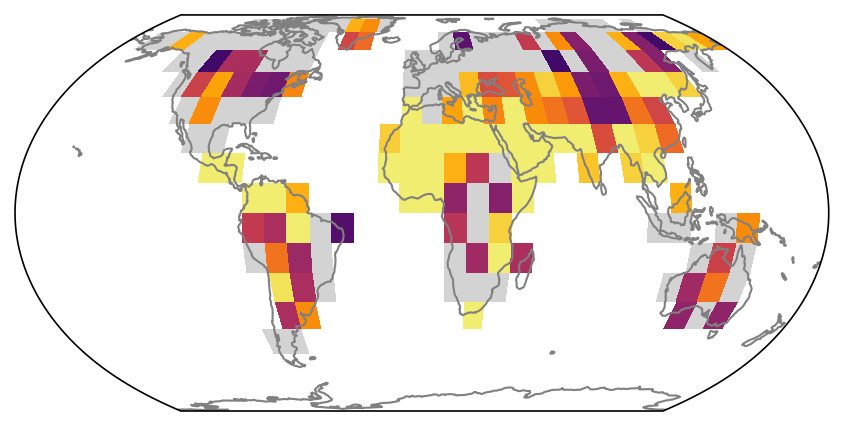

In [12]:
lr_firstpositive[landmask] = np.nan

plt.figure(figsize=(7,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.set_facecolor('lightgrey')
ax.pcolormesh(lonvec+5,latvec+5,obsfirstpositive_climo,vmin=cbarcorrection[0],vmax=cbarcorrection[1],cmap='inferno_r',transform=ccrs.PlateCarree())
ax.pcolormesh(lonvec + 5, latvec + 5, ocean_color, cmap='binary', vmin=0, vmax=1, transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

In [13]:
early_emerge = np.empty((18,36))+np.nan
median_emerge = np.empty((18,36))+np.nan
mean_emerge = np.empty((18,36))+np.nan
climo_emerge = np.empty((18,36))+np.nan

maxyearrank = np.empty((18,36,3))+np.nan
emergeyear = np.empty((18,36,3))+np.nan

gmt_perturb_vec = np.arange(-0.5,2.5,0.05)

for ilat,lat in enumerate(latvec):

    # predsoutfile = "predictions/MPI_histrecord_avgtime_"+str(outputavgtime)+"_obs_lat_"+str(lat)+"_perturbGMT.pkl"
    predsoutfile = "predictions/MPI_recordtemp_avgtime_"+str(outputavgtime)+"_obs_lat_"+str(lat)+"_perturbGMT.pkl"

    with open(predsoutfile,'rb') as f:

        allperturb = pickle.load(f)

    perturbs = allperturb[0]
    climos = allperturb[1]

    meanperturb = np.mean(perturbs,axis=1)
    meanclimo = np.mean(climos,axis=1)

    for ilon in range(36):

        if ~np.isnan(meanperturb[ilon,0,0]):
            early_emerge[ilat,ilon] = helpers.firstpositive(np.nanmax((meanperturb),axis=-1)[ilon],gmt_perturb_vec)
            median_emerge[ilat,ilon] = helpers.firstpositive(np.nanmedian((meanperturb),axis=-1)[ilon],gmt_perturb_vec)

            mean_emerge[ilat,ilon] = helpers.firstpositive(np.nanmean((meanperturb),axis=-1)[ilon],gmt_perturb_vec)

            climo_emerge[ilat,ilon] = helpers.firstpositive(meanclimo[ilon],gmt_perturb_vec)
            emerge1 = np.copy(meanperturb)

            if ~np.isnan(early_emerge[ilat,ilon]):

                for ipeak in range(3):
                    
                    emergegmtind = helpers.firstpositive(np.sort(emerge1[ilon],axis=-1)[:,-1-ipeak],np.arange(60))
                    emergeyear[ilat,ilon,ipeak] = np.argsort(emerge1[ilon],axis=-1)[emergegmtind,-1-ipeak]
            

            # meangmtperturb = np.mean(perturbs,axis=(1,2))[ilon]

            # padded_meangmtperturb = np.pad(meangmtperturb, (1, 1), mode='constant', constant_values=-np.inf)
            # peaks, _ = np.argsort(meangmtperturb)
            # peaks = peaks-1
            # # Sort peaks by peak height
            # top_3_indices = peaks[np.argsort(meangmtperturb[peaks])[-3:][::-1]]

        # maxyearrank[ilat,ilon] = top_3_indices

maxyearrank = maxyearrank+1979
maxyearrank = np.reshape(maxyearrank,(18*36,3))

emergeyear = emergeyear+1979
emergeyear = np.reshape(emergeyear,(18*36,3))

In [ ]:
correctionfactor

0.3566800907995571

In [27]:
obsinputgmt[-1]+correctionfactor

array([1.33136366])

In [15]:
if addgmtcorrection:

    early_emerge = early_emerge+correctionfactor
    climo_emerge = climo_emerge+correctionfactor

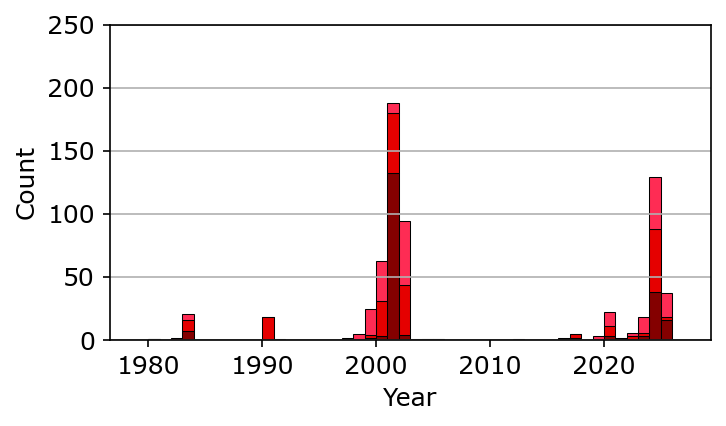

In [16]:

# Define integer bin boundaries covering your timeseries length (e.g., 0 to 50)
timeseries_length = 48 
bins = np.arange(0, timeseries_length + 1, 1)+1979

plt.figure(figsize=(5, 3))
# plt.figure(figsize=(8, 3))
plt.grid(axis='y')

ax=plt.hist(
    # [maxyearrank[:, 0], maxyearrank[:, 1], maxyearrank[:, 2]],
    [emergeyear[:, 0], emergeyear[:, 1], emergeyear[:, 2]],
    bins=bins,
    stacked=True,
    color=['xkcd:dark red', 'xkcd:red', 'xkcd:reddish pink'],  # Blue (bottom), Orange (middle), Green (top)
    label=['1st emergence', '2nd emergence', '3rd emergence'],
    edgecolor='black',
    linewidth=0.5
)

plt.ylim(0,250)
plt.xlabel('Year')
plt.ylabel('Count')
# plt.title()
# plt.legend(loc='upper left', 
#     bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()

plt.show()

In [17]:
obsinputgmt[-1].squeeze()+correctionfactor

1.3313636608784976

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_38418/4227058718.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


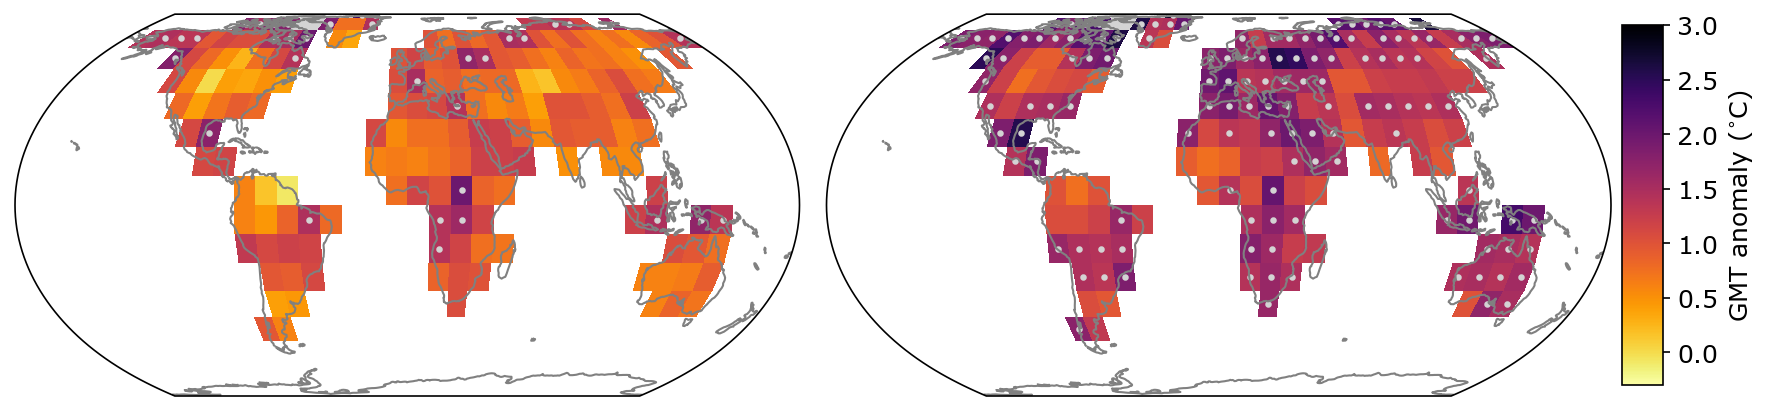

In [18]:
early_emerge[landmask] = np.nan
climo_emerge[landmask] = np.nan

if addgmtcorrection:

    early_emerge_mask_lat_fut = latmesh[early_emerge>(obsinputgmt[-1].squeeze()+correctionfactor)]
    early_emerge_mask_lon_fut = lonmesh[early_emerge>(obsinputgmt[-1].squeeze()+correctionfactor)]

    # early_emerge_mask_lat_hist = latmesh[early_emerge<obsinputgmt[-1].squeeze()]
    # early_emerge_mask_lon_hist = lonmesh[early_emerge<obsinputgmt[-1].squeeze()]

    climo_emerge_mask_lat_fut = latmesh[climo_emerge>(obsinputgmt[-1].squeeze()+correctionfactor)]
    climo_emerge_mask_lon_fut = lonmesh[climo_emerge>(obsinputgmt[-1].squeeze()+correctionfactor)]

else:

    early_emerge_mask_lat_fut = latmesh[early_emerge>obsinputgmt[-1].squeeze()]
    early_emerge_mask_lon_fut = lonmesh[early_emerge>obsinputgmt[-1].squeeze()]

    # early_emerge_mask_lat_hist = latmesh[early_emerge<obsinputgmt[-1].squeeze()]
    # early_emerge_mask_lon_hist = lonmesh[early_emerge<obsinputgmt[-1].squeeze()]

    climo_emerge_mask_lat_fut = latmesh[climo_emerge>obsinputgmt[-1].squeeze()]
    climo_emerge_mask_lon_fut = lonmesh[climo_emerge>obsinputgmt[-1].squeeze()]


if addgmtcorrection:
    cbarearlyemerge = [-0.3,3]
else:
    cbarearlyemerge = [-0.5,2.5]

plt.figure(figsize=(11,3))

# plt.figure(figsize=(11,8))

ax1=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
ax1.pcolormesh(lonvec+5,latvec+5,early_emerge,vmin=cbarearlyemerge[0],vmax=cbarearlyemerge[1],cmap='inferno_r',transform=ccrs.PlateCarree())
ax1.set_facecolor('lightgrey')
ax1.coastlines(color='gray')
ax1.pcolormesh(lonvec + 5, latvec + 5, ocean_color, cmap='binary', vmin=0, vmax=1, transform=ccrs.PlateCarree())
# ax1.scatter(early_emerge_mask_lon_hist,early_emerge_mask_lat_hist,transform=ccrs.PlateCarree(),color='white',marker='x',s=1)
ax1.scatter(early_emerge_mask_lon_fut,early_emerge_mask_lat_fut,transform=ccrs.PlateCarree(),color='lightgrey',marker='.',s=18)

ax2=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
ax2.set_facecolor('lightgrey')
c2=ax2.pcolormesh(lonvec+5,latvec+5,climo_emerge,vmin=cbarearlyemerge[0],vmax=cbarearlyemerge[1],cmap='inferno_r',transform=ccrs.PlateCarree())
ax2.coastlines(color='gray')
ax2.pcolormesh(lonvec + 5, latvec + 5, ocean_color, cmap='binary', vmin=0, vmax=1, transform=ccrs.PlateCarree())
ax2.scatter(climo_emerge_mask_lon_fut,climo_emerge_mask_lat_fut,transform=ccrs.PlateCarree(),color='lightgrey',marker='.',s=18)

dot_handle = mlines.Line2D([], [], color='xkcd:gray', marker='.', linestyle='None', 
                           markersize=10, label='Emergence after 2025')

grey_patch = mpatches.Patch(color='lightgrey', label='No emergence predicted')

# ax2.legend(
#     handles=[dot_handle, grey_patch], 
#     loc='center left',             # Anchor the left edge of the legend box
#     bbox_to_anchor=(1.05, 0.5),    # Position it just past the right edge (1.0) of the map
#     frameon=True,
#     fontsize=16
# )

cax = plt.axes((0.99,0.1,0.025,0.8))
cbar = plt.colorbar(c2,cax)
cbar.ax.set_ylabel('GMT anomaly ($^{\circ}$C)')

plt.tight_layout()


In [19]:
lat = 40

# predsoutfile = "predictions/MPI_histrecord_avgtime_"+str(outputavgtime)+"_obs_lat_"+str(lat)+"_perturbGMT.pkl"
predsoutfile = "predictions/MPI_recordtemp_avgtime_"+str(outputavgtime)+"_obs_lat_"+str(lat)+"_perturbGMT.pkl"

In [20]:
with open(predsoutfile,'rb') as f:

    allperturb = pickle.load(f)

perturbs = allperturb[0]
climos = allperturb[1]

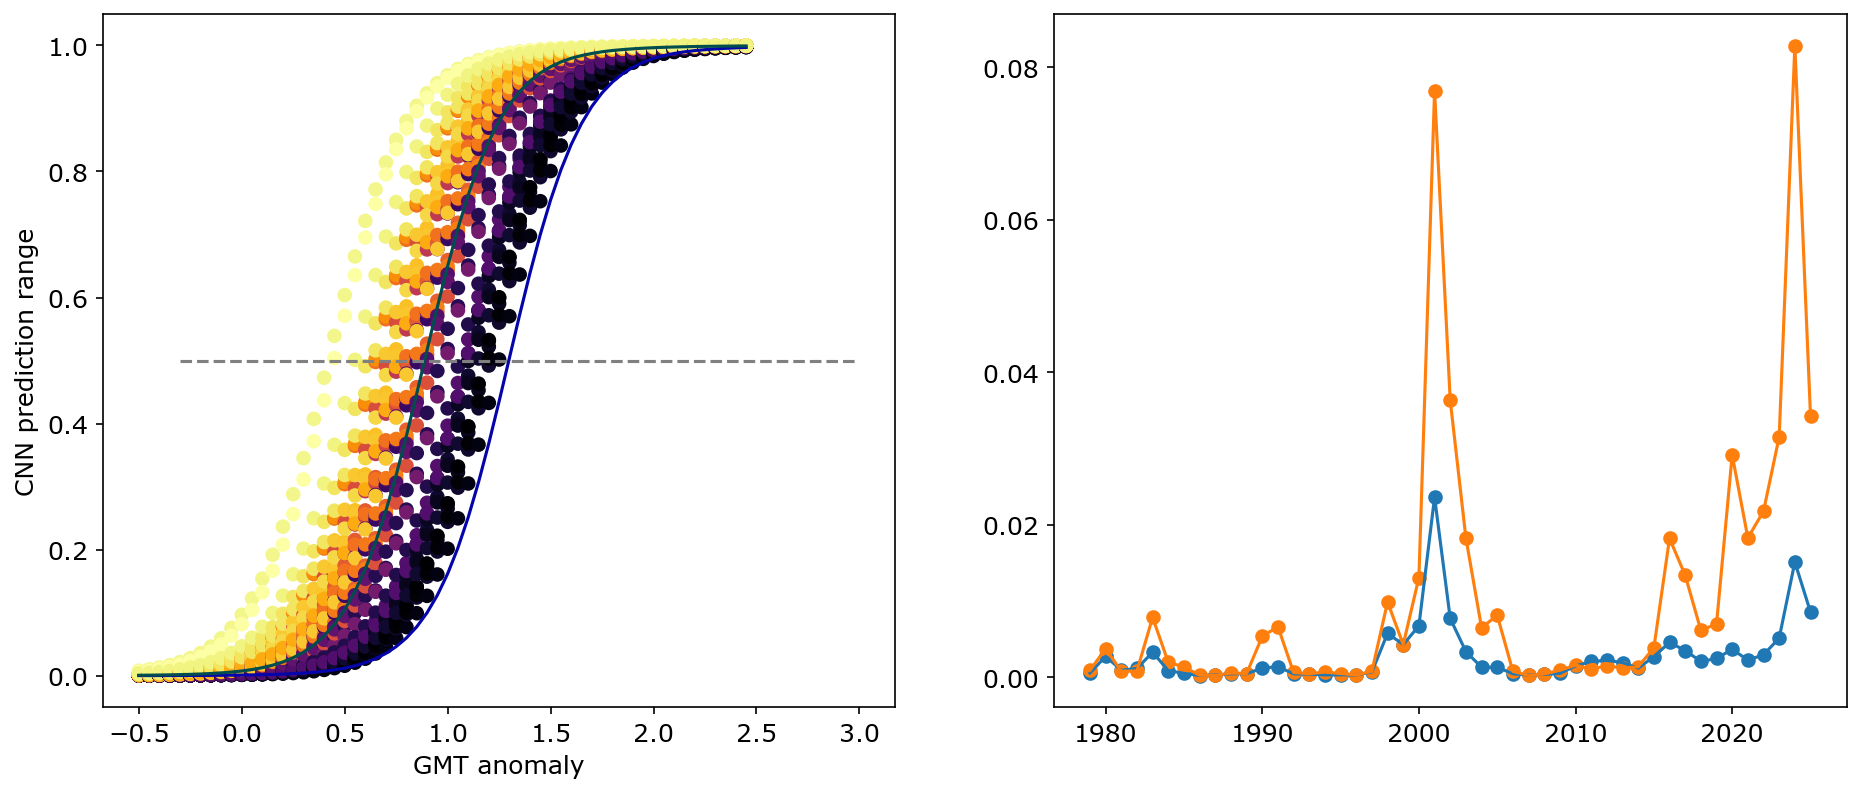

In [21]:
# gmtmat = np.tile(np.arange(-0.3,3,0.05),(perturbs.shape[-1],1))

lonsel = 4
loncomp = 24

gmtvec = np.arange(-0.5,2.5,0.05)

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)

for igmt,gmt in enumerate(gmtvec):

    plt.scatter(gmt*np.ones(47),perturbs[lonsel,0,igmt,:],c=perturbs[loncomp,0,20,],cmap='inferno')

plt.plot(gmtvec,climos[lonsel,0],color='xkcd:royal blue')
plt.plot(gmtvec,np.median(perturbs[lonsel,0,:,:,],axis=-1),color='xkcd:dark teal')

plt.hlines(0.5,-0.3,3,linestyle='dashed',color='grey')

plt.ylabel('CNN prediction range')
plt.xlabel('GMT anomaly')

plt.subplot(1,2,2)

plt.plot(np.arange(1979,2026),np.mean(perturbs,axis=1)[lonsel,7,:])
plt.scatter(np.arange(1979,2026),np.mean(perturbs,axis=1)[lonsel,7,:])

plt.plot(np.arange(1979,2026),np.mean(perturbs,axis=1)[loncomp,7,:])
plt.scatter(np.arange(1979,2026),np.mean(perturbs,axis=1)[loncomp,7,:])

# plt.plot(gmtvec,perturbs[1,0,:,:])

Top 3 peak indices: [45 22 41]
Top 3 peak values: [0.4513056  0.43876245 0.4208257 ]


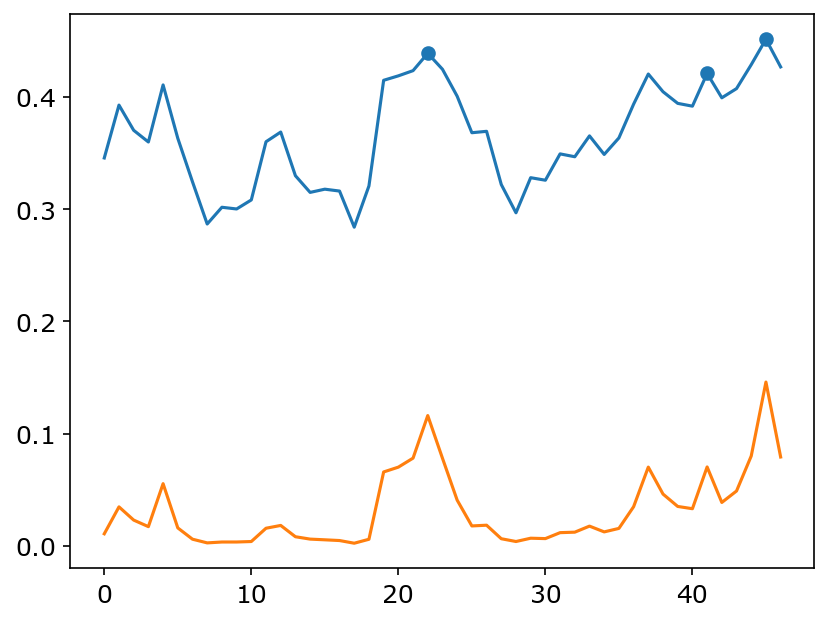

In [22]:
plt.plot(np.mean(perturbs,axis=(1,2))[0])

plt.plot(np.mean(perturbs,axis=1)[0,28])
data = np.mean(perturbs,axis=(1,2))[0]

padded_data = np.pad(data, (1, 1), mode='constant', constant_values=-np.inf)
peaks, _ = find_peaks(padded_data)
peaks = peaks-1
# Sort peaks by peak height
top_3_indices = peaks[np.argsort(data[peaks])[-3:][::-1]]

print("Top 3 peak indices:", top_3_indices)
print("Top 3 peak values:", data[top_3_indices])

# 2. Sort the peaks by height and select the top 3 highest peak indices
# top_3_indices = peaks[np.argsort(properties["peak_heights"])[-3:][::-1]]

plt.scatter(top_3_indices,np.mean(perturbs,axis=(1,2))[0,top_3_indices])

In [23]:
top_3_indices

array([45, 22, 41])

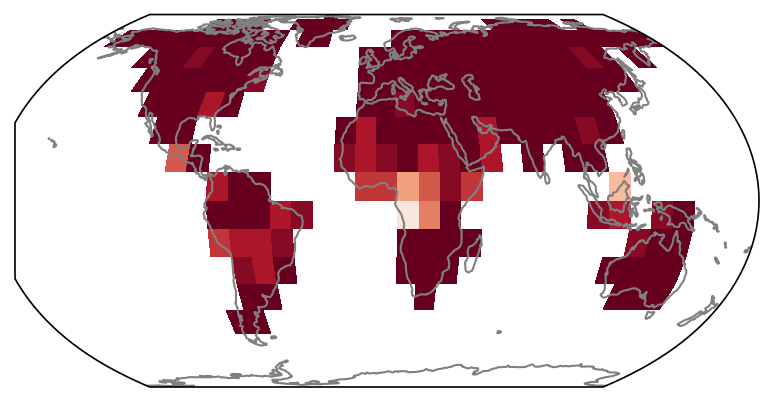

In [24]:
ax3=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax3.pcolormesh(lonvec+5,latvec+5,climo_emerge-median_emerge,vmin=-0.5,vmax=0.5,cmap='RdBu_r',transform=ccrs.PlateCarree())
ax3.coastlines(color='gray')

In [25]:
plt.hist((maxyear+1980).flatten(),bins=np.arange(1980,2024,1))

NameError: name 'maxyear' is not defined

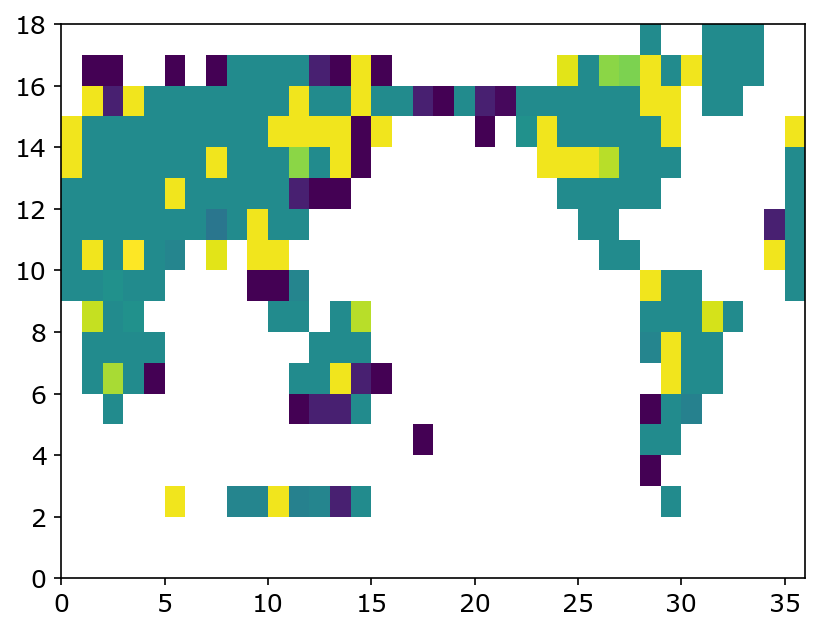

In [ ]:
plt.pcolormesh(maxyear+1980,)

In [ ]:
_,_,allinputtest = AllData.trainvaltest_recordmax_withrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-10,0)
_,_,ssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,-10)
inputGMTtest = allinputtest[1].squeeze()

firstpred_MPI = np.empty((12,18,36))+np.nan

regenerate = True

for ilat,lat in enumerate(latvec):

    if (lat>0) & (regenerate):

        _,_,allinputtest = AllData.trainvaltest_recordmax_withrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,lat,0)
        inputGMTtest = allinputtest[1].squeeze()
        _,_,ssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,lat)

        regenerate = False


    LEpreds = "predictions/MPI_histrecord_avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_testing.pkl"
    filecheck = glob.glob(LEpreds)

    if len(filecheck) != 0:
        with open(LEpreds,'rb') as f:
            predictions = pickle.load(f)
        
        histtag = ssptest==-0.2
        ssp370tag = ssptest==-0.1

        nhist = int(len(ssptest[histtag])/len(trainvaltest[-1]))
        n370 = int(len(ssptest[ssp370tag])/len(trainvaltest[-1]))

        reshapepred = np.empty((36,3,len(trainvaltest[-1]),nhist+n370))
        reshapeGMT = np.empty((len(trainvaltest[-1]),nhist+n370))

        for i in range(len(trainvaltest[-1])):
            
            histinds = [i*nhist,(i+1)*nhist]
            sspinds = nhist*len(trainvaltest[-1])+np.array([i*n370,(i+1)*n370])
            
            allinds = np.concatenate((np.arange(histinds[0],histinds[-1]),np.arange(sspinds[0],sspinds[-1])))

            reshapepred[:,:,i,:] = predictions[:,:,allinds]
            reshapeGMT[i] = inputGMTtest[allinds]

            for ilon in range(36):
                if ~np.isnan(predictions[ilon,0,0]):
                    firstpred_MPI[i,ilat,ilon,] = helpers.firstpositive(np.mean(reshapepred[ilon,:,i,:],axis=0),reshapeGMT[i])

# obsfirstpositive[ilat,ilon] = helpers.firstpositive(obspredavg,obsinputgmt)


baseline for temp records is 0 50
indices of future period are 104 -9
working on 370
indices of future period are 104 -9
working on 370
baseline for temp records is 0 50
indices of future period are 104 -9
working on 370
indices of future period are 104 -9
working on 370


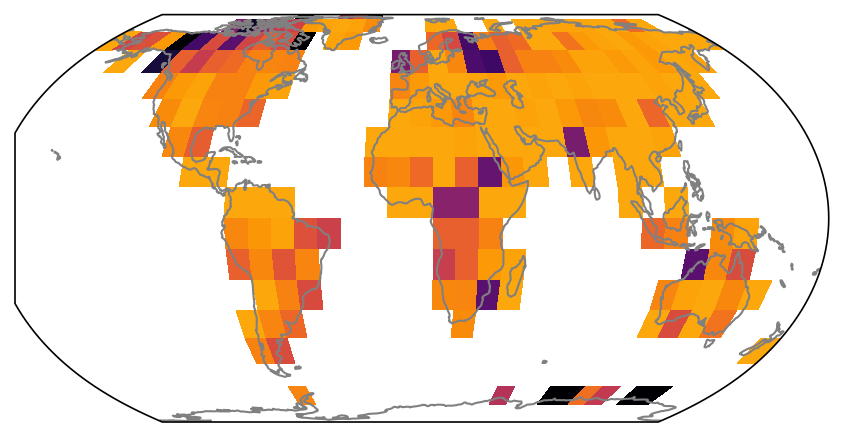

In [ ]:
plt.figure(figsize=(7,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,np.nanmin(firstpred_MPI,axis=0),vmin=-0.25,vmax=1,cmap='inferno_r',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_90774/526845647.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  obspred_now[iseed] = obspred[:,1]
/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_90774/526845647.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  priorrecordplot[ilat,ilon] = obsinputpriorrecord[-1]+AllObs.regionalmean
/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_90774/526845647.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Depr

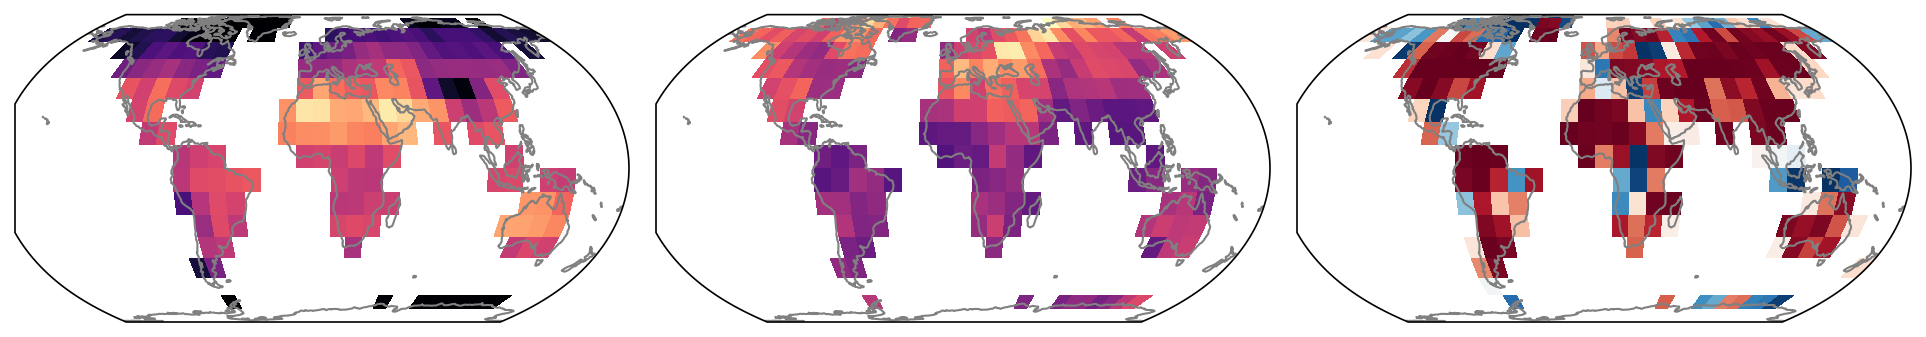

In [ ]:
nboots = 500
autocorr = 3

perturbgmt = np.arange(-0.2,3.1,0.5)

allobsnow = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
allobspeturb = np.empty((len(AllObs.output_lat),len(AllObs.output_lon),len(perturbgmt)))+np.nan

priorrecordplot = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
priorrecordanom = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

for ilat,lat in enumerate(AllObs.output_lat):

    for ilon,lon in enumerate(AllObs.output_lon):

        metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed*.json"
        filelist = glob.glob(metricsout)

        if len(filelist)!=0:
            # print('models exist, proceeding')

            bestseeds = helpers.get_best_files(filelist,n_best)
            # obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)
            obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)

            obsinput_t = torch.tensor(obsinput[[-1]],dtype=torch.float32)
            obsinputgmt_t = torch.tensor(obsinputgmt[[-1]],dtype=torch.float32)
            obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord[[-1]],dtype=torch.float32)
            obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)
            
            obsinput_perturb = obsinput_t*torch.ones((len(perturbgmt),obsinput_t.shape[1],obsinput_t.shape[2],obsinput_t.shape[3]))
            obsinputgmt_perturb = torch.tensor(perturbgmt[:,np.newaxis],dtype=torch.float32)
            obsinputpriorrecord_perturb = obsinputpriorrecord_t*torch.ones(obsinputgmt_perturb.size())
            obsinputvectors_perturb = torch.cat((obsinputgmt_perturb,obsinputpriorrecord_perturb),axis=-1)

            obspredall = np.empty((3,len(obsinput_perturb)))
            obspred_now = np.empty(3)

            for iseed,seed in enumerate(bestseeds):
                # load the model

                loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed_"+str(seed)+".pt"
                cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
                cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
                cnn.to(device)

                with torch.no_grad():
                    cnn.eval()
                    obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()
                    obspred_perturb = cnn(obsinput_perturb.to(device), obsinputvectors_perturb.to(device)).cpu().numpy()

                obspred_now[iseed] = obspred[:,1]
                obspredall[iseed] = obspred_perturb[:,1]

            obspredavg = np.mean(obspredall,axis=0)
            obspredclass = np.round(obspredavg)

            allobsnow[ilat,ilon] = np.mean(obspred_now)
            allobspeturb[ilat,ilon] = obspredavg

            priorrecordplot[ilat,ilon] = obsinputpriorrecord[-1]+AllObs.regionalmean
            priorrecordanom[ilat,ilon] = obsinputpriorrecord[-1]


plt.figure(figsize=(13,5))

a1=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,priorrecordplot-273.15,transform=ccrs.PlateCarree(),vmin=10,vmax=38,cmap='magma')
a1.coastlines(color='grey')

a1=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,priorrecordanom,transform=ccrs.PlateCarree(),vmin=0,vmax=5,cmap='magma')
a1.coastlines(color='grey')

a2=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
a2.pcolormesh(lonvec+5,latvec+5,allobsnow,vmin=0,vmax=1,cmap="RdBu_r",transform=ccrs.PlateCarree())
# a2.scatter(lonsig_climo,latsig_climo,marker='x',transform=ccrs.PlateCarree(),color='grey')
a2.coastlines(color='grey')

plt.tight_layout()
# plt.colorbar()

In [ ]:
R = 287
dT = 2
a = 6e6
y = (60-15)*2*np.pi/360
f = 2*7.272e-5*np.sin(np.deg2rad(38))
p = 250
ps = 100


dU = ((dT*R)/(a*y*f))*np.log(250/1000)
dU


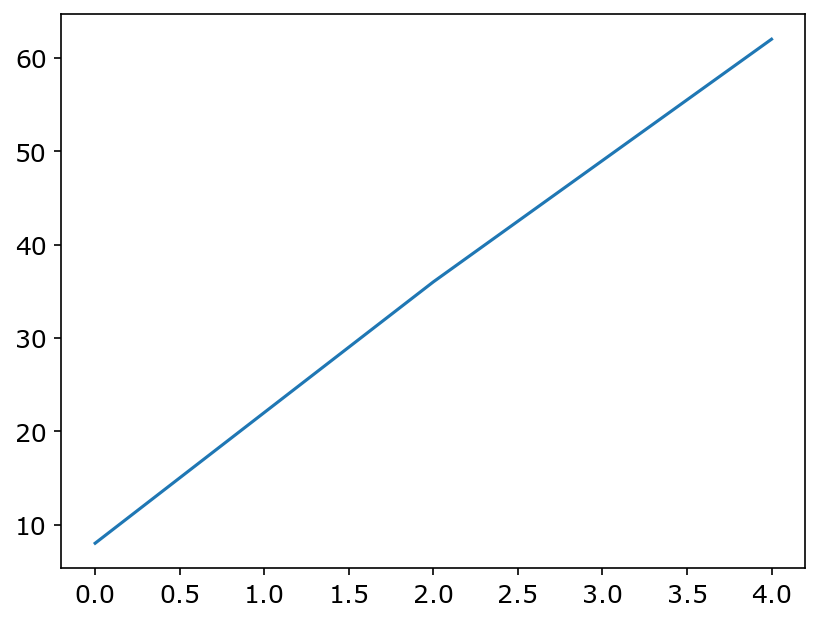

In [ ]:
plt.plot([0,1,2,3,4],[8,22,36,49,62])